In [2]:
import pandas as pd
import numpy as np
import datetime
import time
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from igtrader.Strategies.CrossEMA import CrossEMA, CrossEMAConfig
from igtrader.Strategies.BuyTrendFollowing import BuyTrendFollowing, BuyTrendConfig
from igtrader.Strategies.SellTrendFollowing import SellTrendFollowing, SellTrendConfig
from igtrader.Strategies.BuyHeikinGreen import BuyHeikinGreen, BuyHeikinGreenConfig
from igtrader.Strategies.Strategy import StrategyBaseConfig


/home/hugo/miniconda3/envs/IGTradingBot/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hugo/Repositories/Finance/ig-trading-bot/igtrader/backtestingpy/backtesting/_plotting.py:56: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [3]:
def generate_candles(num_candles=1000, start_date=None, freq='1min'):
    """
    Génère un ensemble de bougies pour le benchmark.
    
    :param num_candles: Nombre de bougies à générer
    :param start_date: Date de début (par défaut: maintenant - num_candles*minutes)
    :param freq: Fréquence des bougies (par défaut: 1 minute)
    :return: DataFrame avec les bougies
    """
    if start_date is None:
        start_date = datetime.datetime.now() - datetime.timedelta(minutes=num_candles)
    
    # Générer les dates
    dates = pd.date_range(start=start_date, periods=num_candles, freq=freq)
    
    # Générer des prix aléatoires mais réalistes
    base_price = 15000  # Prix de base (comme pour le NASDAQ)
    volatility = 50     # Volatilité (écart standard des mouvements)
    
    # Générer les mouvements de prix avec une marche aléatoire
    price_changes = np.random.normal(0, volatility, num_candles)
    cumulative_changes = np.cumsum(price_changes)
    
    # Générer les prix OHLC
    prices = pd.DataFrame()
    prices['date'] = dates
    prices['Close'] = base_price + cumulative_changes
    
    # Générer Open, High, Low à partir de Close avec une certaine volatilité intraday
    intraday_vol = volatility * 0.3
    prices['Open'] = prices['Close'].shift(1, fill_value=base_price) + np.random.normal(0, intraday_vol, num_candles)
    prices['High'] = np.maximum(prices[['Open', 'Close']].max(axis=1) + abs(np.random.normal(0, intraday_vol, num_candles)), 
                               prices[['Open', 'Close']].max(axis=1))
    prices['Low'] = np.minimum(prices[['Open', 'Close']].min(axis=1) - abs(np.random.normal(0, intraday_vol, num_candles)),
                              prices[['Open', 'Close']].min(axis=1))
    
    # S'assurer que High est toujours le plus élevé et Low le plus bas
    prices['High'] = np.maximum(prices['High'], prices[['Open', 'Close']].max(axis=1))
    prices['Low'] = np.minimum(prices['Low'], prices[['Open', 'Close']].min(axis=1))
    
    return prices

In [4]:
import mplfinance as mpf
import matplotlib.pyplot as plt

def visualize_candles(candles, n_candles=100, title="Bougies générées"):
    """
    Affiche un graphique en chandelier des données générées.
    
    :param candles: DataFrame avec les données OHLC (doit avoir des colonnes 'Open', 'High', 'Low', 'Close')
    :param n_candles: Nombre de bougies à afficher (pour éviter de surcharger le graphique)
    :param title: Titre du graphique
    """
    # Préparation des données
    df = candles.copy()
    
    # S'assurer que la date est en index
    if 'date' in df.columns:
        df = df.set_index('date')
    
    # Limiter le nombre de bougies pour la clarté
    if len(df) > n_candles:
        df = df.iloc[-n_candles:]
    
    # Configuration du style
    mc = mpf.make_marketcolors(up='g', down='r',
                               edge='inherit',
                               wick={'up':'g', 'down':'r'},
                               volume='inherit')
    
    s = mpf.make_mpf_style(base_mpf_style='yahoo', 
                           marketcolors=mc,
                           gridstyle=':',
                           y_on_right=False)
    
    # Création du graphique
    fig, axes = mpf.plot(df, type='candle', style=s,
                         title=title,
                         figsize=(12, 8),
                         volume=False,
                         ylabel='Prix',
                         returnfig=True)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes

In [5]:
def run_benchmark(strategy, candles, batch_size=1):
    """
    Exécute le benchmark en envoyant des bougies à la stratégie.
    
    :param strategy: L'instance de stratégie à tester
    :param candles: DataFrame contenant les bougies de test
    :param batch_size: Nombre de bougies à envoyer à chaque itération
    """
    # Initialiser avec un ensemble de bougies historiques
    historical_size = min(50, len(candles) // 5)  # 20% des bougies pour l'initialisation
    historical_candles = candles.iloc[:historical_size].copy()
    
    strategy.initialize(historical_candles)
    
    # Activer le benchmark
    strategy.start_benchmark()
    
    # Traiter les bougies restantes
    remaining_candles = candles.iloc[historical_size:].copy()
    
    for i in range(0, len(remaining_candles), batch_size):
        batch = remaining_candles.iloc[i:i+batch_size]
        
        for _, candle in batch.iterrows():
            # Convertir la Series en dictionnaire
            candle_dict = candle.to_dict()
            
            # Mise à jour de la stratégie avec la nouvelle bougie
            strategy.update_candle(candle_dict)
    
    # Désactiver le benchmark
    strategy.stop_benchmark()
    
    return strategy.get_benchmark_stats()

def display_results(stats):
    """Affiche les résultats du benchmark."""
    print("\n=== RÉSULTATS DU BENCHMARK ===")
    
    # Tableau de statistiques
    table = [
        ["Nombre de bougies", stats["count"]],
        ["Temps d'exécution moyen", f"{stats['mean']:.2f} ms"],
        ["Temps d'exécution médian", f"{stats['median']:.2f} ms"],
        ["Temps minimum", f"{stats['min']:.2f} ms"],
        ["Temps maximum", f"{stats['max']:.2f} ms"],
        ["95ème percentile", f"{stats['p95']:.2f} ms"],
        ["99ème percentile", f"{stats['p99']:.2f} ms"],
        ["Temps total", f"{stats['total']:.2f} ms ({stats['total']/1000:.2f} s)"]
    ]
    
    print(tabulate(table, headers=["Métrique", "Valeur"], tablefmt="grid"))
    
    # Si vous souhaitez ajouter des visualisations avec matplotlib, vous pouvez le faire ici
    if stats["count"] > 0 and "execution_times" in stats:
        plt.figure(figsize=(12, 6))
        
        # Histogramme des temps d'exécution
        plt.subplot(1, 2, 1)
        
        # Filtrer les données pour n'inclure que celles jusqu'au 99ème percentile
        filtered_times = [t for t in stats["execution_times"] if 0.2 <= t <= stats['p99']]
        sns.histplot(filtered_times, kde=True)
        plt.title("Distribution des temps d'exécution")
        plt.xlabel("Temps (ms)")
        plt.ylabel("Fréquence")
        
        # Graphique d'évolution des temps d'exécution
        plt.subplot(1, 2, 2)
        plt.plot(stats["execution_times"])
        plt.title("Évolution des temps d'exécution")
        plt.xlabel("Itération")
        plt.ylabel("Temps (ms)")
        plt.xlim(0, len(stats["execution_times"]) - 1)  # Définir l'axe x pour commencer à 0
        plt.yscale('log')  # Échelle logarithmique pour l'axe y
        
        plt.tight_layout()

2025-04-28 21:07:33,076 - INFO - Génération de 24570 bougies pour le test...
/home/hugo/miniconda3/envs/IGTradingBot/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
2025-04-28 21:07:33,130 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-04-28 21:07:33,132 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-04-28 21:07:33,135 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-04-28

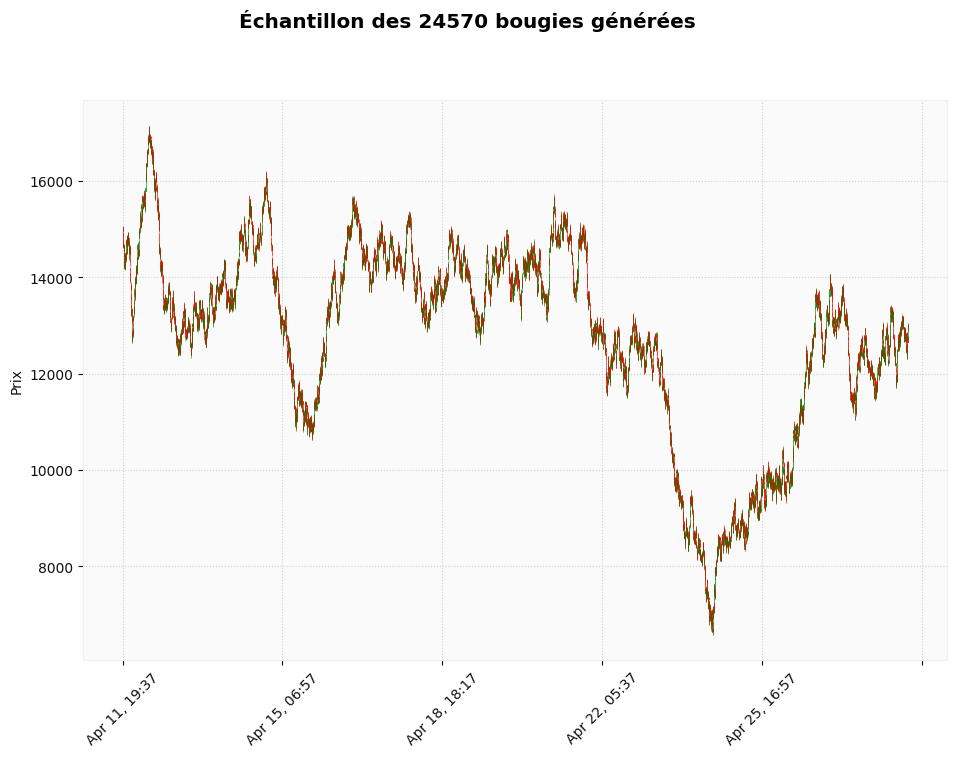

(<Figure size 1200x800 with 2 Axes>, [<Axes: ylabel='Prix'>, <Axes: >])

In [6]:
# Configuration du logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Paramètres du benchmark
num_candle_2_y = 589680 # bougies de 20 secondes sur 2 ans
num_candle_6_m = num_candle_2_y // 4 # bougies de 20 secondes sur 6 mois
num_candle_1_m = num_candle_2_y // 24 # bougies de 20 secondes sur 1 mois

num_candles = num_candle_1_m

# Générer les données de test
logging.info(f"Génération de {num_candles} bougies pour le test...")
candles = generate_candles(num_candles)

visualize_candles(candles, n_candles=num_candles, title=f"Échantillon des {num_candles} bougies générées")

2025-04-24 19:01:56,139 - INFO - Démarrage du benchmark...
2025-04-24 19:02:18,729 - INFO - Benchmark terminé en 22.59 secondes



=== RÉSULTATS DU BENCHMARK ===
+--------------------------+-----------------------+
| Métrique                 | Valeur                |
+==========================+=======================+
| Nombre de bougies        | 24520                 |
+--------------------------+-----------------------+
| Temps d'exécution moyen  | 0.79 ms               |
+--------------------------+-----------------------+
| Temps d'exécution médian | 0.78 ms               |
+--------------------------+-----------------------+
| Temps minimum            | 0.71 ms               |
+--------------------------+-----------------------+
| Temps maximum            | 1.77 ms               |
+--------------------------+-----------------------+
| 95ème percentile         | 0.87 ms               |
+--------------------------+-----------------------+
| 99ème percentile         | 1.14 ms               |
+--------------------------+-----------------------+
| Temps total              | 19389.84 ms (19.39 s) |
+-------------

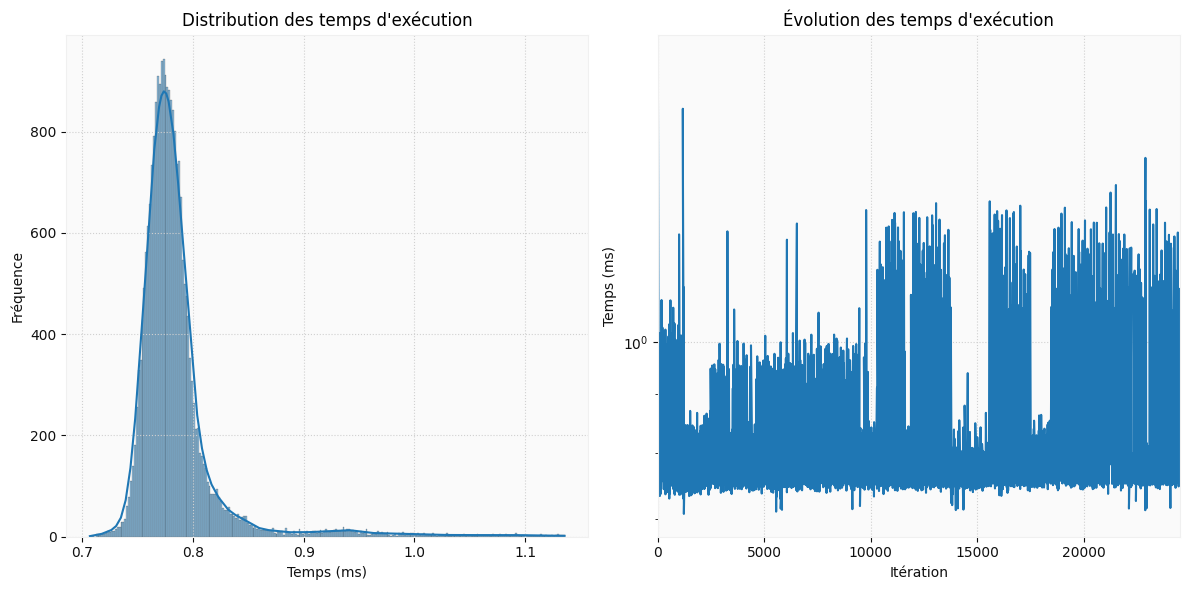

In [7]:
# Créer la stratégie
base_config = StrategyBaseConfig(
    trading_from=datetime.time(0, 0),  # Toute la journée pour le benchmark
    trading_to=datetime.time(23, 59),
    trading_days=[0, 1, 2, 3, 4, 5, 6],  # Tous les jours pour le benchmark
    take_profit_distance=30,
    stop_loss_distance=20,
)
crossEMA_config = CrossEMAConfig(
    ema_short_period=50,
    ema_long_period=200,
)

# strategy = CrossEMA(base_config, crossEMA_config)
# strategy = BuyTrendFollowing(base_config, BuyTrendConfig())
strategy = BuyHeikinGreen(base_config, BuyHeikinGreenConfig())

# Exécuter le benchmark
logging.info("Démarrage du benchmark...")
start_time = time.time()
stats = run_benchmark(strategy, candles)
total_time = time.time() - start_time

# Ajouter le temps d'exécution total pour la visualisation
stats["execution_times"] = strategy.execution_times

# Afficher les résultats
logging.info(f"Benchmark terminé en {total_time:.2f} secondes")
display_results(stats)


2025-04-24 18:59:14,270 - INFO - Démarrage du benchmark...
2025-04-24 18:59:36,881 - INFO - Benchmark terminé en 22.61 secondes



=== RÉSULTATS DU BENCHMARK ===
+--------------------------+--------------------+
| Métrique                 | Valeur             |
+==========================+====================+
| Nombre de bougies        | 1000               |
+--------------------------+--------------------+
| Temps d'exécution moyen  | 0.78 ms            |
+--------------------------+--------------------+
| Temps d'exécution médian | 0.78 ms            |
+--------------------------+--------------------+
| Temps minimum            | 0.75 ms            |
+--------------------------+--------------------+
| Temps maximum            | 0.86 ms            |
+--------------------------+--------------------+
| 95ème percentile         | 0.80 ms            |
+--------------------------+--------------------+
| 99ème percentile         | 0.82 ms            |
+--------------------------+--------------------+
| Temps total              | 780.38 ms (0.78 s) |
+--------------------------+--------------------+


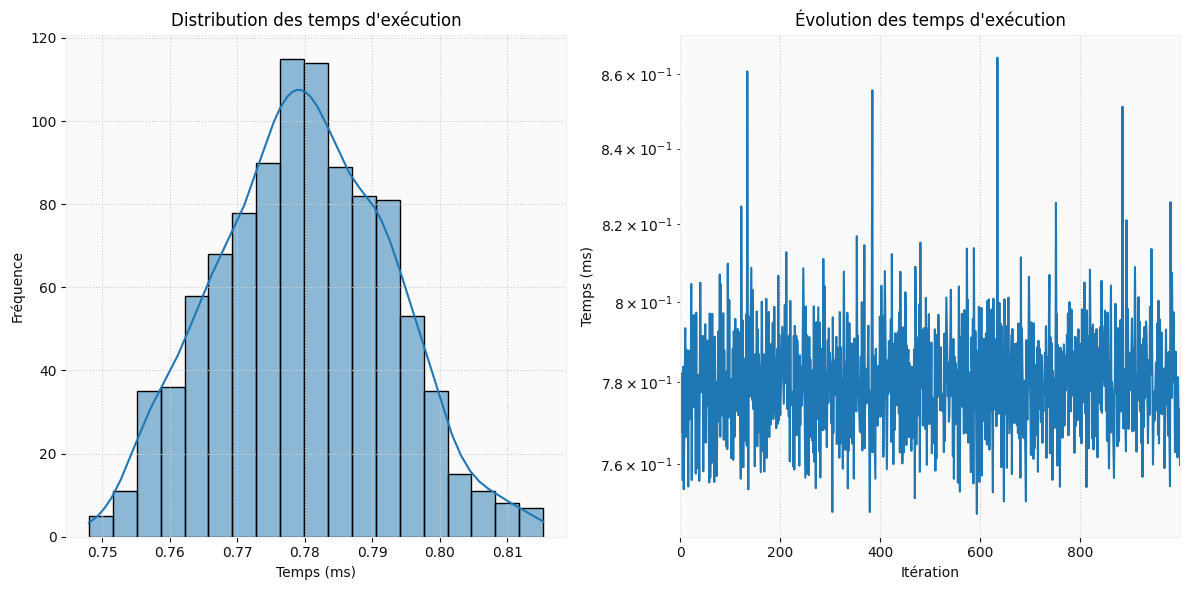

In [14]:
# Créer la stratégie
base_config = StrategyBaseConfig(
    trading_from=datetime.time(0, 0),  # Toute la journée pour le benchmark
    trading_to=datetime.time(23, 59),
    trading_days=[0, 1, 2, 3, 4, 5, 6],  # Tous les jours pour le benchmark
    take_profit_distance=30,
    stop_loss_distance=20,
)
crossEMA_config = CrossEMAConfig(
    ema_short_period=50,
    ema_long_period=200,
)

# strategy = CrossEMA(base_config, crossEMA_config)
# strategy = BuyTrendFollowing(base_config, BuyTrendConfig())
strategy = BuyHeikinGreen(base_config, BuyHeikinGreenConfig())

# Exécuter le benchmark
logging.info("Démarrage du benchmark...")
start_time = time.time()
stats = run_benchmark(strategy, candles)
total_time = time.time() - start_time

# Ajouter le temps d'exécution total pour la visualisation
stats["execution_times"] = strategy.execution_times

# Afficher les résultats
logging.info(f"Benchmark terminé en {total_time:.2f} secondes")
display_results(stats)


2025-04-28 21:07:48,156 - INFO - Démarrage du benchmark...
2025-04-28 21:08:10,014 - INFO - Benchmark terminé en 21.86 secondes



=== RÉSULTATS DU BENCHMARK ===
+--------------------------+-----------------------+
| Métrique                 | Valeur                |
+==========================+=======================+
| Nombre de bougies        | 24520                 |
+--------------------------+-----------------------+
| Temps d'exécution moyen  | 0.77 ms               |
+--------------------------+-----------------------+
| Temps d'exécution médian | 0.77 ms               |
+--------------------------+-----------------------+
| Temps minimum            | 0.69 ms               |
+--------------------------+-----------------------+
| Temps maximum            | 2.02 ms               |
+--------------------------+-----------------------+
| 95ème percentile         | 0.82 ms               |
+--------------------------+-----------------------+
| 99ème percentile         | 0.93 ms               |
+--------------------------+-----------------------+
| Temps total              | 18963.82 ms (18.96 s) |
+-------------

2025-04-28 21:08:10,269 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2025-04-28 21:08:10,270 - DEBUG - findfont: score(FontEntry(fname='/home/hugo/miniconda3/envs/IGTradingBot/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Bold.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2025-04-28 21:08:10,270 - DEBUG - findfont: score(FontEntry(fname='/home/hugo/miniconda3/envs/IGTradingBot/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-04-28 21:08:10,270 - DEBUG - findfont: score(FontEntry(fname='/home/hugo/miniconda3/envs/IGTradingBot/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBol.ttf', name='STIXNonUnicode', style='normal', variant='normal', weight=700, 

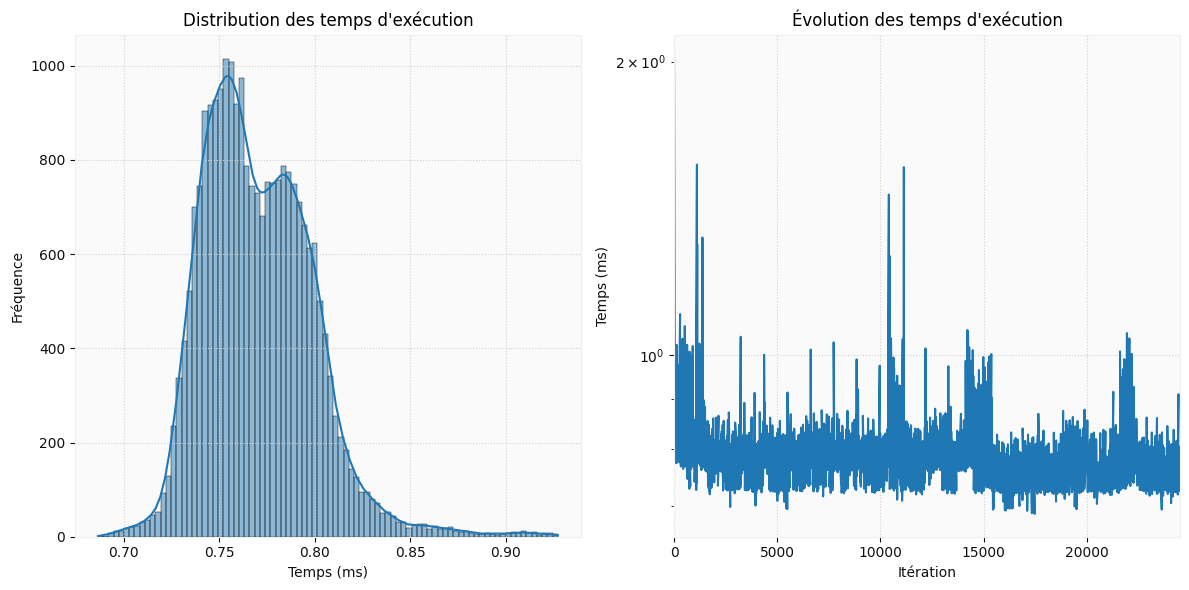

In [7]:
# Créer la stratégie
base_config = StrategyBaseConfig(
    trading_from=datetime.time(0, 0),  # Toute la journée pour le benchmark
    trading_to=datetime.time(23, 59),
    trading_days=[0, 1, 2, 3, 4, 5, 6],  # Tous les jours pour le benchmark
    take_profit_distance=30,
    stop_loss_distance=20,
)
crossEMA_config = CrossEMAConfig(
    ema_short_period=50,
    ema_long_period=200,
)

# strategy = CrossEMA(base_config, crossEMA_config)
# strategy = BuyTrendFollowing(base_config, BuyTrendConfig())
strategy = BuyHeikinGreen(base_config, BuyHeikinGreenConfig())

# Exécuter le benchmark
logging.info("Démarrage du benchmark...")
start_time = time.time()
stats = run_benchmark(strategy, candles)
total_time = time.time() - start_time

# Ajouter le temps d'exécution total pour la visualisation
stats["execution_times"] = strategy.execution_times

# Afficher les résultats
logging.info(f"Benchmark terminé en {total_time:.2f} secondes")
display_results(stats)
